In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Stochastic Mass-Spring-Damper**
The physical model is
$$
m\ddot{q} + c \dot{q} + kq = F(t) + \sigma \dot{W}_t.
$$
With $x = [q, v]^\top$,
$$
\mathrm{d}X = (AX + Bu)\mathrm{d}t + M \mathrm{d}W_t.
$$

A_true =
 [[ 0.   1. ]
 [-2.  -0.4]]
B_true =
 [[0.]
 [1.]]
M_true =
 [[0.  ]
 [0.15]]


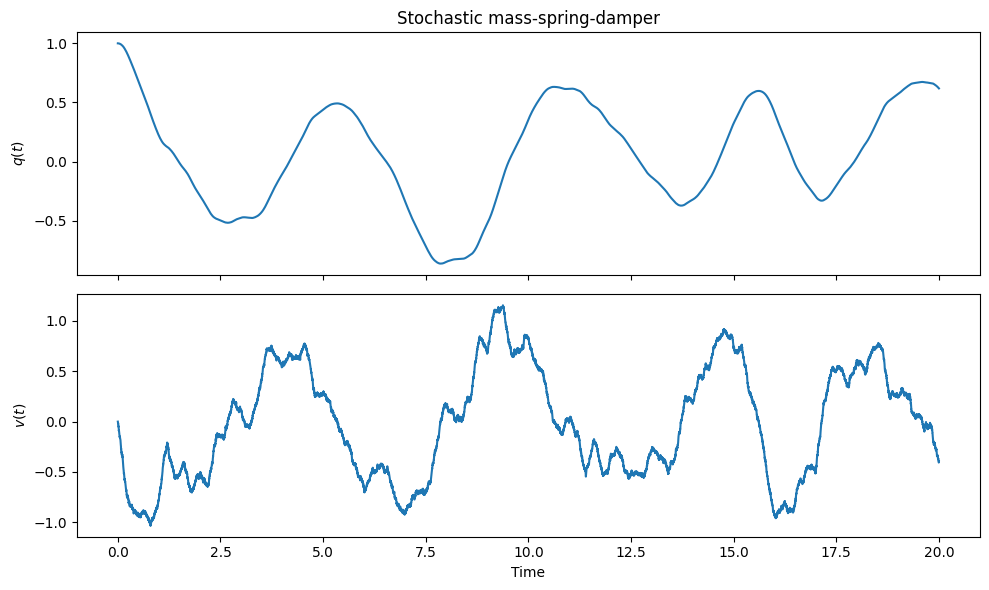

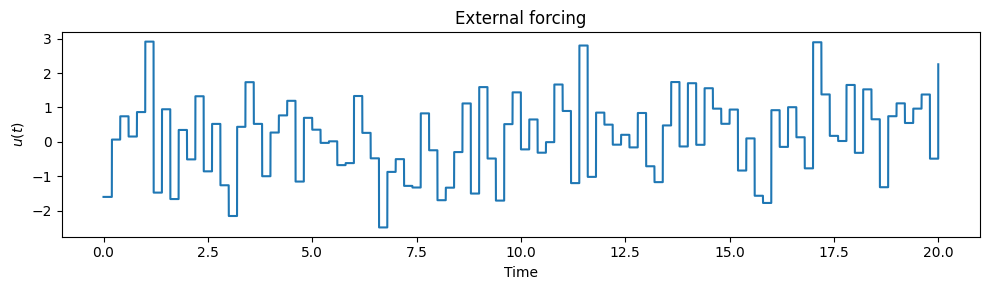

In [2]:
# Physical parameters

m = 1.0       # mass
c = 0.4       # damping
k = 2.0       # stiffness
sigma = 0.15  # stochastic forcing strength


# True operators
A_true = np.array([
    [0.0,       1.0],
    [-k / m, -c / m]
])

B_true = np.array([
    [0.0],
    [1.0 / m]
])

M_true = np.array([
    [0.0],
    [sigma / m]
])


print("A_true =\n", A_true)
print("B_true =\n", B_true)
print("M_true =\n", M_true)


# Time discretization
T = 20.0
dt = 1e-3

t = np.arange(0.0, T + dt, dt)
K = len(t)


# Input

# Random piecewise-constant forcing
rng = np.random.default_rng(1234)

block_size = 200
n_blocks = int(np.ceil(K / block_size))

u_blocks = rng.normal(0.0, 1.0, n_blocks)

u = np.repeat(u_blocks, block_size)[:K]


# Simulate stochastic system

X = np.zeros((K, 2))

# Initial condition
X[0] = [1.0, 0.0]

for n in range(K - 1):

    x = X[n]

    # deterministic drift
    drift = A_true @ x + B_true[:, 0] * u[n]

    # Wiener increment
    dW = np.sqrt(dt) * rng.normal()

    # Euler-Maruyama
    X[n + 1] = (
        x
        + drift * dt
        + M_true[:, 0] * dW
    )


# Plot state trajectories
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(t, X[:, 0])
ax[0].set_ylabel(r"$q(t)$")
ax[0].set_title("Stochastic mass-spring-damper")

ax[1].plot(t, X[:, 1])
ax[1].set_ylabel(r"$v(t)$")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


# Plot input
plt.figure(figsize=(10, 3))
plt.plot(t, u)
plt.xlabel("Time")
plt.ylabel(r"$u(t)$")
plt.title("External forcing")
plt.tight_layout()
plt.show()

In [3]:
# Construct OpInf regression

# Use all but final snapshot
Xk = X[:-1]
Xkp1 = X[1:]
uk = u[:-1]

# Derivative approximation
Y = (Xkp1 - Xk) / dt

# Regression matrix
D = np.column_stack([
    Xk,
    uk
])

print("D shape:", D.shape)
print("Y shape:", Y.shape)


# Ordinary least-squares OpInf

O_ls, *_ = np.linalg.lstsq(D, Y, rcond=None)

# O_ls has shape (3, 2)
# First two rows correspond to A^T
# Last row corresponds to B^T

A_ls = O_ls[:2, :].T
B_ls = O_ls[2:, :].T

print("\nTrue A:")
print(A_true)

print("\nEstimated A:")
print(A_ls)

print("\nTrue B:")
print(B_true)

print("\nEstimated B:")
print(B_ls)

D shape: (20000, 3)
Y shape: (20000, 2)

True A:
[[ 0.   1. ]
 [-2.  -0.4]]

Estimated A:
[[-1.20846508e-16  1.00000000e+00]
 [-1.87629761e+00 -4.37833675e-01]]

True B:
[[0.]
 [1.]]

Estimated B:
[[1.07274876e-16]
 [9.99245887e-01]]


In [4]:
# Bayesian OpInf posterior

def bayesian_opinf_posterior(D, Y, lam):
    """
    Bayesian linear regression corresponding to the
    formulation used in Bayesian OpInf.

    Parameters
    ----------
    D : ndarray, shape (K, d)
        Regression matrix.
    Y : ndarray, shape (K, r)
        Target matrix.
    lam : float
        Tikhonov/Bayesian regularization parameter.

    Returns
    -------
    O_mean : ndarray, shape (d, r)
        Posterior mean.
    covariances : list
        Posterior covariance for each output dimension.
    """

    K, d = D.shape

    DTD = D.T @ D
    H = DTD + lam**2 * np.eye(d)

    # Posterior mean = Tikhonov solution
    O_mean = np.linalg.solve(
        H,
        D.T @ Y
    )

    covariances = []

    for i in range(Y.shape[1]):

        yi = Y[:, i]
        oi = O_mean[:, i]

        # Bayesian OpInf residual variance
        sigma2 = (
            np.linalg.norm(D @ oi - yi)**2
            + lam**2 * np.linalg.norm(oi)**2
        ) / K

        covariance = sigma2 * np.linalg.inv(H)

        covariances.append(covariance)

    return O_mean, covariances

lam = 1e-2

O_mean, covariances = bayesian_opinf_posterior(
    D,
    Y,
    lam
)


A_bayes = O_mean[:2, :].T
B_bayes = O_mean[2:, :].T


print("\nBayesian posterior mean A:")
print(A_bayes)

print("\nBayesian posterior mean B:")
print(B_bayes)


Bayesian posterior mean A:
[[-1.78485807e-09  9.99999982e-01]
 [-1.87629756e+00 -4.37833663e-01]]

Bayesian posterior mean B:
[[1.3455456e-09]
 [9.9924588e-01]]


In [5]:
# Sample drift operators from posterior

n_samples = 1000

O_samples = []

for j in range(n_samples):

    O_sample = np.zeros_like(O_mean)

    for i in range(Y.shape[1]):

        O_sample[:, i] = rng.multivariate_normal(
            mean=O_mean[:, i],
            cov=covariances[i]
        )

    O_samples.append(O_sample)

O_samples = np.asarray(O_samples)

print("O_samples shape:", O_samples.shape)

O_samples shape: (1000, 3, 2)


In [6]:
A21_samples = O_samples[:, 1, 0]

mean_A21 = np.mean(A21_samples)
std_A21 = np.std(A21_samples)

print("True A21:", A_true[1, 0])
print("Posterior mean:", mean_A21)
print("Posterior std:", std_A21)

True A21: -2.0
Posterior mean: 0.999999954637673
Posterior std: 9.454945051273772e-07


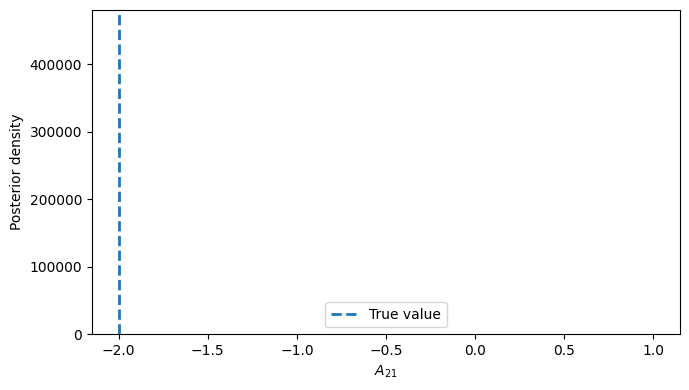

In [7]:
plt.figure(figsize=(7, 4))

plt.hist(
    A21_samples,
    bins=50,
    density=True
)

plt.axvline(
    A_true[1, 0],
    linestyle="--",
    linewidth=2,
    label="True value"
)

plt.xlabel(r"$A_{21}$")
plt.ylabel("Posterior density")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Propagate posterior samples

n_pred = 100

X_pred = np.zeros((n_pred, K, 2))

for j in range(n_pred):

    O = O_samples[j]

    A = O[:2, :].T
    B = O[2:, :].T

    Xj = np.zeros((K, 2))
    Xj[0] = X[0]

    # Independent Wiener process
    dW = np.sqrt(dt) * rng.normal(size=K - 1)

    for n in range(K - 1):

        drift = (
            A @ Xj[n]
            + B[:, 0] * u[n]
        )

        Xj[n + 1] = (
            Xj[n]
            + drift * dt
            + M_true[:, 0] * dW[n]
        )

    X_pred[j] = Xj

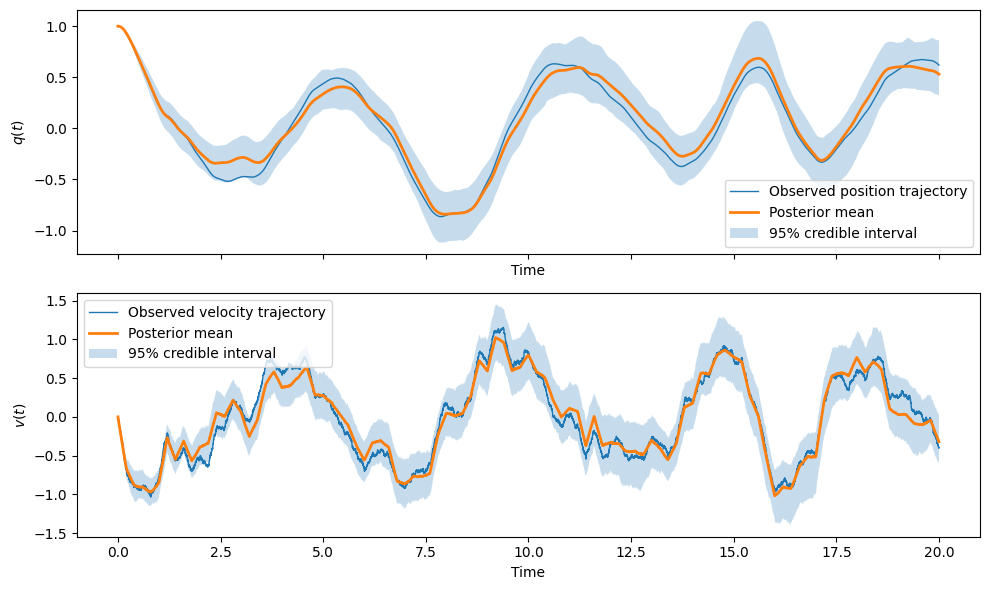

In [ ]:
# Posterior predictive uncertainty (position)

q_mean = X_pred[:, :, 0].mean(axis=0)
q_lower = np.percentile(X_pred[:, :, 0], 2.5, axis=0)
q_upper = np.percentile(X_pred[:, :, 0], 97.5, axis=0)

# Posterior predictive uncertainty (velocity)

v_mean = X_pred[:, :, 1].mean(axis=0)
v_lower = np.percentile(X_pred[:, :, 1], 2.5, axis=0)
v_upper = np.percentile(X_pred[:, :, 1], 97.5, axis=0)


fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t, X[:, 0], linewidth=1, label="Observed position trajectory")

axs[0].plot(
    t,
    q_mean,
    linewidth=2,
    label="Posterior mean"
)

axs[0].fill_between(
    t,
    q_lower,
    q_upper,
    alpha=0.25,
    label="95% credible interval"
)

axs[1].plot(t, X[:, 1], linewidth=1, label="Observed velocity trajectory")

axs[1].plot(
    t,
    v_mean,
    linewidth=2,
    label="Posterior mean"
)

axs[1].fill_between(
    t,
    v_lower,
    v_upper,
    alpha=0.25,
    label="95% credible interval"
)

axs[0].set_xlabel("Time")
axs[0].set_ylabel(r"$q(t)$")
axs[0].legend()
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$v(t)$")
axs[1].legend()

plt.tight_layout()
plt.show()

## **Stochastic Duffing Oscillator**


In [ ]:
# ============================================================
# 1. Physical parameters
# ============================================================

m = 1.0
c = 0.25
k = 1.0
alpha = 1.0

# Stochastic forcing strength
sigma = 0.20


# True Duffing coefficients
print("True physical parameters")
print("------------------------")
print("m     =", m)
print("c     =", c)
print("k     =", k)
print("alpha =", alpha)
print("sigma =", sigma)


# ============================================================
# 2. Time discretization
# ============================================================

T = 50.0
dt = 1e-3

t = np.arange(0.0, T + dt, dt)
K = len(t)

print("\nNumber of time steps:", K)


# ============================================================
# 3. External forcing
# ============================================================

rng = np.random.default_rng(1234)

# Random piecewise-constant forcing
block_size = 500

n_blocks = int(np.ceil(K / block_size))

# u_blocks = rng.normal(
#     loc=0.0,
#     scale=1.0,
#     size=n_blocks
# )

u_blocks = rng.uniform(
    -3.0,
    3.0,
    n_blocks
)

u = np.repeat(
    u_blocks,
    block_size
)[:K]


# ============================================================
# 4. True Duffing dynamics
# ============================================================

def duffing_drift(x, u):
    """
    Deterministic Duffing drift.

    x = [q, v]
    """

    q, v = x

    dq = v

    dv = (
        -k / m * q
        -c / m * v
        -alpha / m * q**3
        +1.0 / m * u
    )

    return np.array([dq, dv])


# ============================================================
# 5. Simulate stochastic Duffing oscillator
# ============================================================

X = np.zeros((K, 2))

# Initial condition
X[0] = [0.5, 0.0]

for n in range(K - 1):

    x = X[n]

    # Deterministic drift
    drift = duffing_drift(
        x,
        u[n]
    )

    # Wiener increment
    dW = np.sqrt(dt) * rng.normal()

    # Euler-Maruyama
    X[n + 1] = (
        x
        + drift * dt
        + np.array([0.0, sigma / m]) * dW
    )

True physical parameters
------------------------
m     = 1.0
c     = 0.25
k     = 1.0
alpha = 1.0
sigma = 0.2

Number of time steps: 50001


In [ ]:
# ============================================================
# 6. Plot trajectory
# ============================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True
)

ax[0].plot(t, X[:, 0])
ax[0].set_ylabel(r"$q(t)$")
ax[0].set_title("Stochastic Duffing oscillator")

ax[1].plot(t, X[:, 1])
ax[1].set_ylabel(r"$v(t)$")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Plot phase portrait
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    X[:, 0],
    X[:, 1],
    linewidth=0.8
)

plt.xlabel(r"$q$")
plt.ylabel(r"$v$")
plt.title("Duffing phase portrait")

plt.tight_layout()
plt.show()


# ============================================================
# 8. Plot forcing
# ============================================================

plt.figure(figsize=(10, 3))

plt.plot(t, u)

plt.xlabel("Time")
plt.ylabel(r"$u(t)$")
plt.title("External forcing")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Construct OpInf data
# ============================================================

# State at time k
Xk = X[:-1]

# State at time k+1
Xkp1 = X[1:]

# Input at time k
uk = u[:-1]


# Approximate time derivative
Y = (Xkp1 - Xk) / dt


# ============================================================
# 10. Construct nonlinear dictionary
# ============================================================

q = Xk[:, 0]
v = Xk[:, 1]

D = np.column_stack([
    q,
    v,
    q**3,
    uk
])


print("\nRegression matrix")
print("-----------------")
print("D shape:", D.shape)
print("Y shape:", Y.shape)


# ============================================================
# 11. Ordinary least-squares OpInf
# ============================================================

O_ls, *_ = np.linalg.lstsq(
    D,
    Y,
    rcond=None
)


# O_ls has shape (4, 2)
#
#       q    v    q^3   u
# qdot  ?    ?     ?    ?
# vdot  ?    ?     ?    ?
#
# But the matrix is stored transposed relative
# to the usual operator notation.

O_ls = O_ls.T


print("\nEstimated operator:")
print(O_ls)


# ============================================================
# 12. True operator
# ============================================================

O_true = np.array([
    [
        0.0,
        1.0,
        0.0,
        0.0
    ],
    [
        -k / m,
        -c / m,
        -alpha / m,
        1.0 / m
    ]
])


print("\nTrue operator:")
print(O_true)


# ============================================================
# 13. Compare
# ============================================================

print("\nOperator error:")
print(O_ls - O_true)

print(
    "\nRelative Frobenius error:",
    np.linalg.norm(O_ls - O_true)
    / np.linalg.norm(O_true)
)

In [ ]:
# ============================================================
# 14. Bayesian OpInf using the SDE likelihood
# ============================================================

# State increments
DeltaX = X[1:] - X[:-1]

# Feature matrix
Phi = D.copy()

# ------------------------------------------------------------
# Fixed diffusion operator
# ------------------------------------------------------------

M_fixed = np.array([
    [0.0],
    [sigma / m]
])

Q = M_fixed @ M_fixed.T * dt

print("Diffusion covariance:")
print(Q)


# ============================================================
# 15. Gaussian likelihood
# ============================================================

# For this Duffing system, the noise only enters the
# second state equation. Therefore Q is singular.
#
# To make the first implementation simple, we perform the
# Bayesian regression separately for each state equation.
#
# The first equation has no stochastic forcing:
#
#       dq = v dt
#
# so its regression can be treated deterministically.
#
# The second equation has:
#
#       dv = f_2(q,v,u) dt + sigma/m dW
#
# ============================================================


# ------------------------------------------------------------
# First equation
# ------------------------------------------------------------

phi = Phi

# q equation:
#
# dq/dt = 0*q + 1*v + 0*q^3 + 0*u

lambda_q = 1e-3

H_q = (
    phi.T @ phi
    + lambda_q**2 * np.eye(phi.shape[1])
)

mu_q = np.linalg.solve(
    H_q,
    phi.T @ (DeltaX[:, 0] / dt)
)


# ------------------------------------------------------------
# Second equation
# ------------------------------------------------------------

# For the stochastic equation, the observation variance
# of Delta v is
#
#       Var(Delta v) = (sigma/m)^2 dt

variance_v = (sigma / m)**2 * dt


lambda_v = 1e-3

H_v = (
    phi.T @ phi / variance_v
    + lambda_v**2 * np.eye(phi.shape[1])
)

rhs_v = (
    phi.T @ DeltaX[:, 1] / (variance_v * dt)
)

mu_v = np.linalg.solve(
    H_v,
    rhs_v
)


# ============================================================
# 16. Assemble posterior mean
# ============================================================

O_bayes = np.vstack([
    mu_q,
    mu_v
])

print("\nBayesian posterior mean:")
print(O_bayes)

print("\nTrue operator:")
print(O_true)

print("\nError:")
print(O_bayes - O_true)

Diffusion covariance:
[[0.e+00 0.e+00]
 [0.e+00 4.e-05]]

Bayesian posterior mean:
[[ 2.56162595e-13  1.00000000e+00 -2.13914168e-13  1.34843137e-12]
 [-9.96508274e-01 -2.21828481e-01 -9.97807555e-01  9.95646735e-01]]

True operator:
[[ 0.    1.    0.    0.  ]
 [-1.   -0.25 -1.    1.  ]]

Error:
[[ 2.56162595e-13 -7.87003795e-12 -2.13914168e-13  1.34843137e-12]
 [ 3.49172587e-03  2.81715192e-02  2.19244541e-03 -4.35326534e-03]]


In [ ]:
# Noise variance of derivative data
sigma_y2 = (sigma / m)**2 / dt

print("Derivative noise variance:", sigma_y2)

# Posterior precision
H_v = (
    Phi.T @ Phi / sigma_y2
    + lambda_v**2 * np.eye(Phi.shape[1])
)

# Posterior covariance
Sigma_v = np.linalg.inv(H_v)

# Posterior standard deviation
std_v = np.sqrt(np.diag(Sigma_v))

print("\nPosterior standard deviations:")
print(std_v)

Derivative noise variance: 40.00000000000001

Posterior standard deviations:
[0.06384548 0.01774309 0.03088609 0.01581231]


In [ ]:
print("\n95% credible intervals:")

for j, name in enumerate(["q", "v", "q^3", "u"]):

    lower = mu_v[j] - 1.96 * std_v[j]
    upper = mu_v[j] + 1.96 * std_v[j]

    print(
        f"{name:>3s}: "
        f"{mu_v[j]: .5f} "
        f"[{lower:.5f}, {upper:.5f}] "
        f"true={O_true[1,j]:.5f}"
    )


95% credible intervals:
  q: -0.99651 [-1.12165, -0.87137] true=-1.00000
  v: -0.22183 [-0.25660, -0.18705] true=-0.25000
q^3: -0.99781 [-1.05834, -0.93727] true=-1.00000
  u:  0.99565 [0.96465, 1.02664] true=1.00000


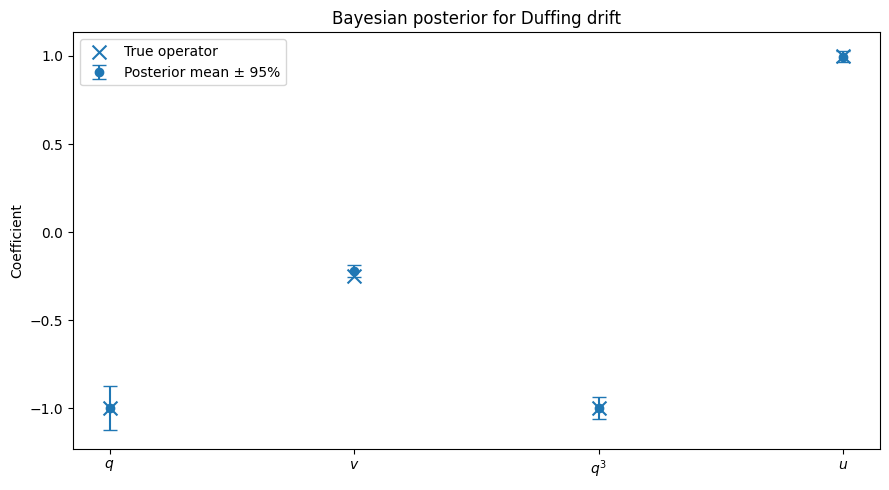

In [ ]:
names = [
    r"$q$",
    r"$v$",
    r"$q^3$",
    r"$u$"
]

x = np.arange(4)

plt.figure(figsize=(9, 5))

plt.errorbar(
    x,
    mu_v,
    yerr=1.96 * std_v,
    fmt="o",
    capsize=5,
    label="Posterior mean ± 95%"
)

plt.scatter(
    x,
    O_true[1],
    marker="x",
    s=100,
    label="True operator"
)

plt.xticks(x, names)
plt.ylabel("Coefficient")
plt.title("Bayesian posterior for Duffing drift")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
std_v = np.sqrt(np.diag(Sigma_v))

Corr_v = Sigma_v / np.outer(std_v, std_v)

print("Posterior correlation matrix:")
print(Corr_v)

Posterior correlation matrix:
[[ 1.         -0.00902148 -0.89320455  0.01473374]
 [-0.00902148  1.          0.01559533 -0.19231213]
 [-0.89320455  0.01559533  1.         -0.05276284]
 [ 0.01473374 -0.19231213 -0.05276284  1.        ]]


In [ ]:
print("corr(q, q^3) =", Corr_v[0, 2])

corr(q, q^3) = -0.8932045505158768


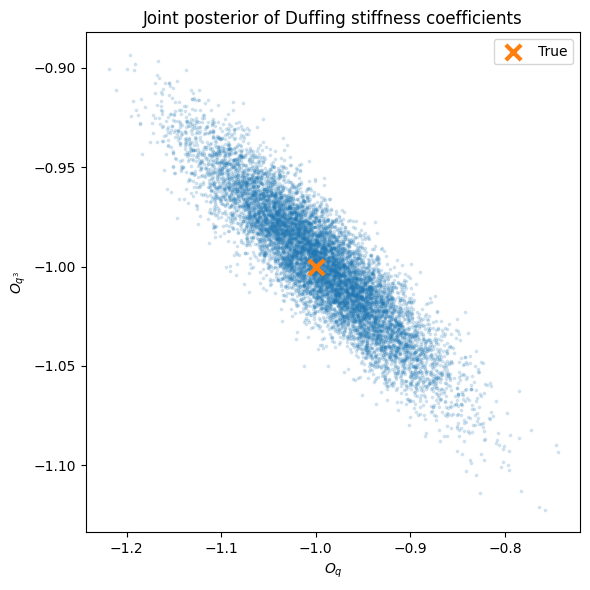

In [ ]:
n_samples = 10000

samples = rng.multivariate_normal(
    mean=mu_v,
    cov=Sigma_v,
    size=n_samples
)

plt.figure(figsize=(6, 6))

plt.scatter(
    samples[:, 0],
    samples[:, 2],
    s=3,
    alpha=0.15
)

plt.scatter(
    O_true[1, 0],
    O_true[1, 2],
    marker="x",
    s=120,
    linewidths=3,
    label="True"
)

plt.xlabel(r"$O_{q}$")
plt.ylabel(r"$O_{q^3}$")
plt.title("Joint posterior of Duffing stiffness coefficients")
plt.legend()

plt.tight_layout()
plt.show()

## **Stochastic Lotka-Volterra**

True operator:
[[ 1.   0.  -0.5]
 [ 0.  -1.   0.5]]


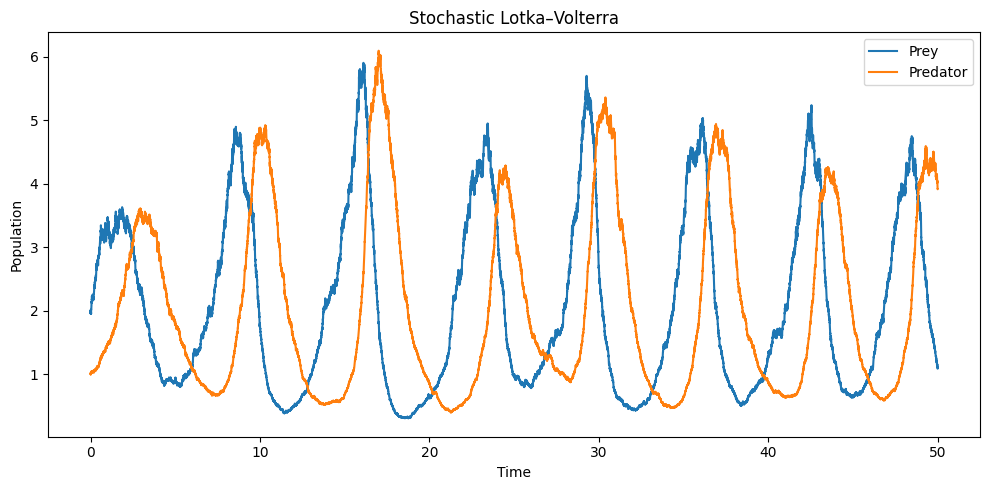

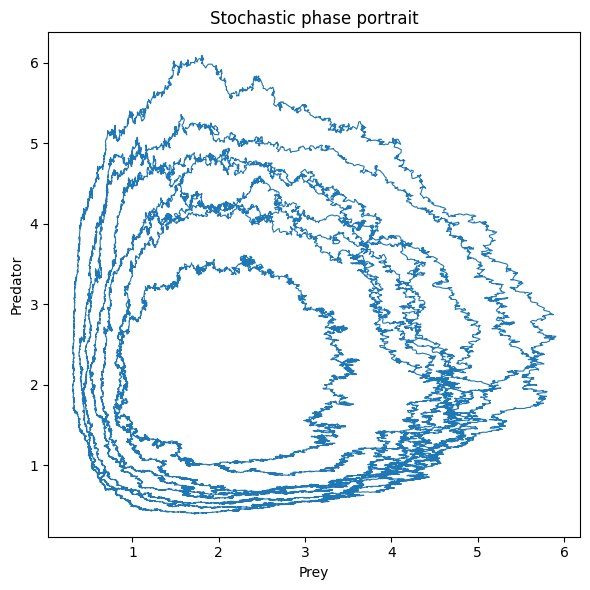

In [ ]:
# ============================================================
# 1. Parameters
# ============================================================

alpha = 1.0
beta = 0.5
delta = 0.5
gamma = 1.0

sigma1 = 0.15
sigma2 = 0.10


# True OpInf operator

O_true = np.array([
    [alpha, 0.0, -beta],
    [0.0, -gamma, delta]
])

print("True operator:")
print(O_true)


# ============================================================
# 2. Time discretization
# ============================================================

T = 50.0
dt = 1e-3

t = np.arange(
    0.0,
    T + dt,
    dt
)

K = len(t)


# ============================================================
# 3. Simulate stochastic Lotka-Volterra
# ============================================================

X = np.zeros((K, 2))

# Initial population
X[0] = [2.0, 1.0]

rng = np.random.default_rng(1234)


for n in range(K - 1):

    x1, x2 = X[n]

    # --------------------------------------------------------
    # Drift
    # --------------------------------------------------------

    f1 = (
        alpha * x1
        - beta * x1 * x2
    )

    f2 = (
        delta * x1 * x2
        - gamma * x2
    )

    # --------------------------------------------------------
    # Multiplicative diffusion
    # --------------------------------------------------------

    M = np.array([
        [sigma1 * x1, 0.0],
        [0.0, sigma2 * x2]
    ])

    # --------------------------------------------------------
    # Wiener increment
    # --------------------------------------------------------

    dW = np.sqrt(dt) * rng.normal(size=2)

    # --------------------------------------------------------
    # Euler-Maruyama
    # --------------------------------------------------------

    X[n + 1] = (
        X[n]
        + np.array([f1, f2]) * dt
        + M @ dW
    )

    # Prevent numerical negativity
    X[n + 1] = np.maximum(
        X[n + 1],
        1e-8
    )


# ============================================================
# 4. Plot populations
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t,
    X[:, 0],
    label="Prey"
)

plt.plot(
    t,
    X[:, 1],
    label="Predator"
)

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Stochastic Lotka–Volterra")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 5. Phase portrait
# ============================================================

plt.figure(figsize=(6, 6))

plt.plot(
    X[:, 0],
    X[:, 1],
    linewidth=0.8
)

plt.xlabel("Prey")
plt.ylabel("Predator")
plt.title("Stochastic phase portrait")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 6. Construct OpInf data
# ============================================================

Xk = X[:-1]

DeltaX = X[1:] - X[:-1]

X1 = Xk[:, 0]
X2 = Xk[:, 1]


# Feature matrix

D = np.column_stack([
    X1,
    X2,
    X1 * X2
])


# Derivative approximation

Y = DeltaX / dt


print("D shape:", D.shape)
print("Y shape:", Y.shape)

D shape: (50000, 3)
Y shape: (50000, 2)


In [33]:
# ============================================================
# 7. Ordinary OpInf
# ============================================================

lam = 1e-4

H = D.T @ D + lam**2 * np.eye(D.shape[1])

O_mean = np.linalg.solve(
    H,
    D.T @ Y
)

print("\nEstimated operator:")
print(O_mean)

print("\nTrue operator:")
print(O_true)

print("\nError:")
print(O_mean.T - O_true)

print(
    "\nRelative error:",
    np.linalg.norm(O_mean.T - O_true)
    / np.linalg.norm(O_true)
)


Estimated operator:
[[ 9.93763662e-01  5.94103786e-03]
 [ 9.14554935e-04 -9.35055851e-01]
 [-4.97058512e-01  4.66867700e-01]]

True operator:
[[ 1.   0.  -0.5]
 [ 0.  -1.   0.5]]

Error:
[[-0.00623634  0.00091455  0.00294149]
 [ 0.00594104  0.06494415 -0.0331323 ]]

Relative error: 0.04647222142854146


In [34]:
# ============================================================
# Bayesian stochastic OpInf
# State-dependent diffusion
# ============================================================

def bayesian_lv_posterior(D, Y, X, dt, sigma1, sigma2, lam):

    K, d = D.shape
    r = Y.shape[1]

    O_mean = np.zeros((d, r))
    covariances = []

    # State-dependent diffusion variances
    x1 = X[:-1, 0]
    x2 = X[:-1, 1]

    variance_1 = sigma1**2 * x1**2 / dt
    variance_2 = sigma2**2 * x2**2 / dt

    variances = [
        variance_1,
        variance_2
    ]

    for i in range(r):

        variance = variances[i]

        # Inverse variance weights
        weights = 1.0 / variance

        # Weighted normal matrix
        H = (
            D.T @ (weights[:, None] * D)
            + lam**2 * np.eye(d)
        )

        # Weighted right-hand side
        rhs = (
            D.T @ (weights * Y[:, i])
        )

        # Posterior covariance
        Sigma = np.linalg.inv(H)

        # Posterior mean
        mu = Sigma @ rhs

        O_mean[:, i] = mu

        covariances.append(Sigma)

    return O_mean, covariances

In [35]:
lam = 1e-4

O_bayes, covariances = bayesian_lv_posterior(
    D,
    Y,
    X,
    dt,
    sigma1,
    sigma2,
    lam
)

print("\nBayesian posterior mean:")
print(O_bayes)

print("\nTrue operator:")
print(O_true)

print("\nError:")
print(O_bayes.T - O_true)


Bayesian posterior mean:
[[ 1.06281565  0.00362783]
 [ 0.021697   -1.0093892 ]
 [-0.53225542  0.49061559]]

True operator:
[[ 1.   0.  -0.5]
 [ 0.  -1.   0.5]]

Error:
[[ 0.06281565  0.021697   -0.03225542]
 [ 0.00362783 -0.0093892  -0.00938441]]


In [36]:
for i in range(2):

    std = np.sqrt(
        np.diag(covariances[i])
    )

    print(f"\nState equation {i+1}")

    for j in range(3):

        lower = (
            O_bayes[j, i]
            - 1.96 * std[j]
        )

        upper = (
            O_bayes[j, i]
            + 1.96 * std[j]
        )

        print(
            f"coefficient {j}: "
            f"{O_bayes[j,i]:.5f} "
            f"[{lower:.5f}, {upper:.5f}]"
        )


State equation 1
coefficient 0: 1.06282 [0.98966, 1.13597]
coefficient 1: 0.02170 [-0.00497, 0.04836]
coefficient 2: -0.53226 [-0.56746, -0.49705]

State equation 2
coefficient 0: 0.00363 [-0.01882, 0.02608]
coefficient 1: -1.00939 [-1.05958, -0.95920]
coefficient 2: 0.49062 [0.46638, 0.51485]


In [37]:
for i in range(2):

    Sigma = covariances[i]

    std = np.sqrt(np.diag(Sigma))

    Corr = Sigma / np.outer(std, std)

    print(f"\nState equation {i+1}")
    print(Corr)


State equation 1
[[ 1.         -0.07144784 -0.63438757]
 [-0.07144784  1.         -0.56744296]
 [-0.63438757 -0.56744296  1.        ]]

State equation 2
[[ 1.         -0.14981788 -0.59422964]
 [-0.14981788  1.         -0.5705593 ]
 [-0.59422964 -0.5705593   1.        ]]


In [38]:
print(
    "corr(alpha, beta) =",
    Corr[0, 2]
)

corr(alpha, beta) = -0.5942296360996652


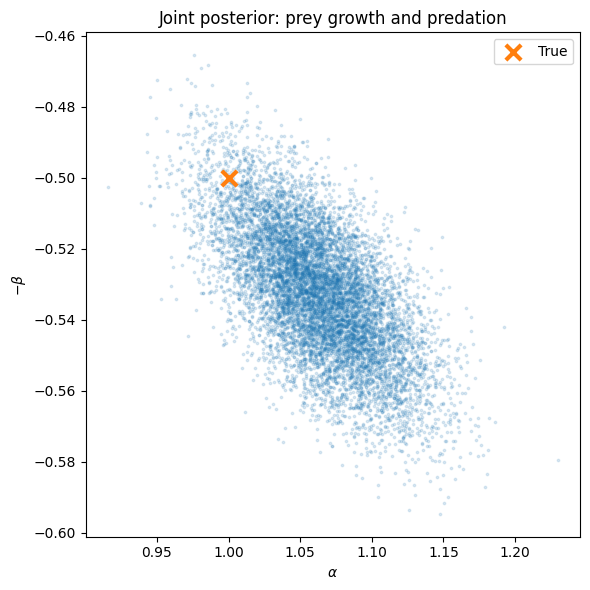

In [39]:
n_samples = 10000

samples_1 = rng.multivariate_normal(
    O_bayes[:, 0],
    covariances[0],
    size=n_samples
)

plt.figure(figsize=(6, 6))

plt.scatter(
    samples_1[:, 0],
    samples_1[:, 2],
    s=3,
    alpha=0.15
)

plt.scatter(
    1.0,
    -0.5,
    marker="x",
    s=120,
    linewidths=3,
    label="True"
)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$-\beta$")
plt.title("Joint posterior: prey growth and predation")
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
n_operator_samples = 100

operator_samples = []

for j in range(n_operator_samples):

    o1 = rng.multivariate_normal(
        mean=O_bayes[:, 0],
        cov=covariances[0]
    )

    o2 = rng.multivariate_normal(
        mean=O_bayes[:, 1],
        cov=covariances[1]
    )

    O_sample = np.column_stack([
        o1,
        o2
    ])

    operator_samples.append(O_sample)

In [41]:
print("Posterior mean:")
print(O_bayes.T)

print("\nSampled operator:")
print(operator_samples[0].T)

print("\nTrue operator:")
print(O_true)

Posterior mean:
[[ 1.06281565  0.021697   -0.53225542]
 [ 0.00362783 -1.0093892   0.49061559]]

Sampled operator:
[[ 1.09262861  0.03022028 -0.57305996]
 [ 0.01381599 -0.97609733  0.4777047 ]]

True operator:
[[ 1.   0.  -0.5]
 [ 0.  -1.   0.5]]


In [42]:
def simulate_lv_operator(
    O,
    X0,
    t,
    sigma1,
    sigma2,
    rng
):

    dt = t[1] - t[0]

    X_sim = np.zeros(
        (len(t), 2)
    )

    X_sim[0] = X0

    for n in range(len(t) - 1):

        x1, x2 = X_sim[n]

        # Features
        phi = np.array([
            x1,
            x2,
            x1 * x2
        ])

        # Drift
        f = O.T @ phi

        # State-dependent diffusion
        M = np.array([
            [sigma1 * x1, 0.0],
            [0.0, sigma2 * x2]
        ])

        # Wiener increment
        dW = np.sqrt(dt) * rng.normal(
            size=2
        )

        # Euler-Maruyama
        X_sim[n + 1] = (
            X_sim[n]
            + f * dt
            + M @ dW
        )

        # Positivity
        X_sim[n + 1] = np.maximum(
            X_sim[n + 1],
            1e-8
        )

    return X_sim

In [43]:
n_samples = 100

X_pred = np.zeros(
    (n_samples, len(t), 2)
)

X0 = X[0]

for j in range(n_samples):

    X_pred[j] = simulate_lv_operator(
        O=operator_samples[j],
        X0=X0,
        t=t,
        sigma1=sigma1,
        sigma2=sigma2,
        rng=rng
    )

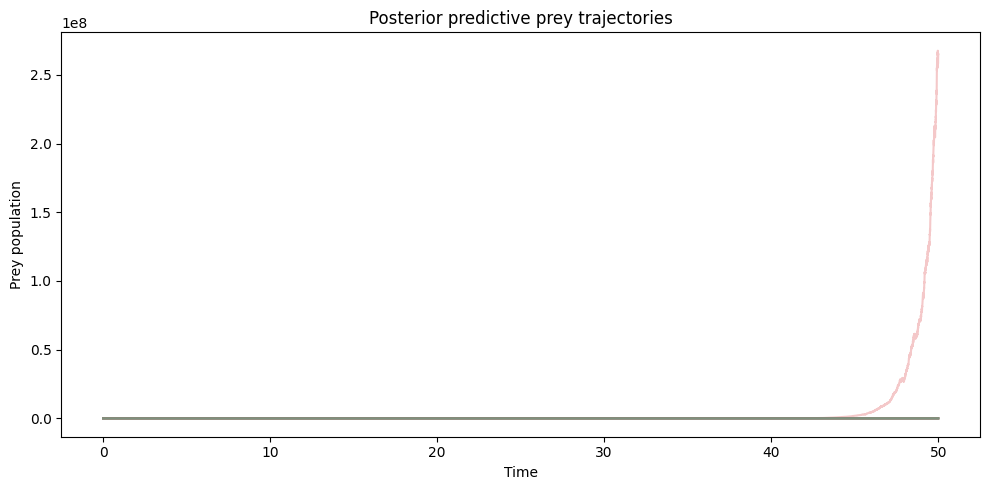

In [44]:
plt.figure(figsize=(10, 5))

for j in range(20):

    plt.plot(
        t,
        X_pred[j, :, 0],
        alpha=0.25
    )

plt.xlabel("Time")
plt.ylabel("Prey population")
plt.title("Posterior predictive prey trajectories")

plt.tight_layout()
plt.show()

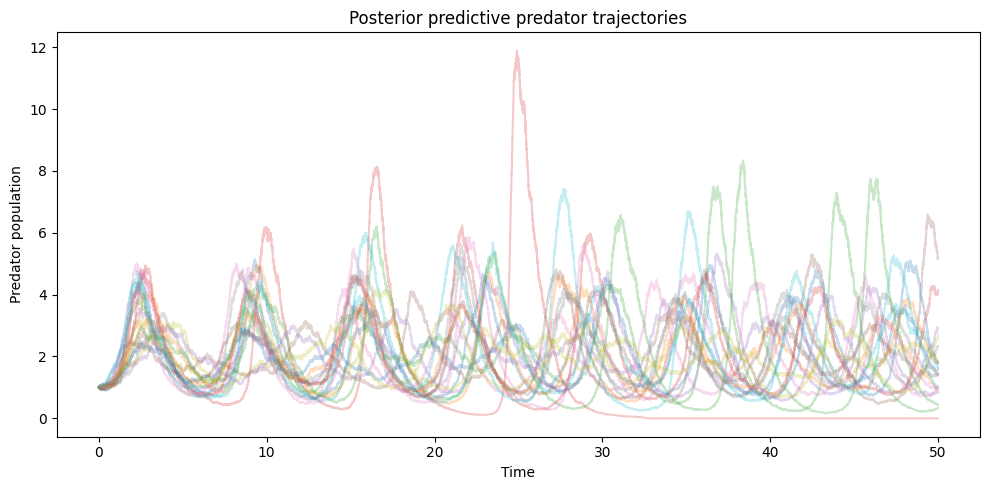

In [45]:
plt.figure(figsize=(10, 5))

for j in range(20):

    plt.plot(
        t,
        X_pred[j, :, 1],
        alpha=0.25
    )

plt.xlabel("Time")
plt.ylabel("Predator population")
plt.title("Posterior predictive predator trajectories")

plt.tight_layout()
plt.show()

In [46]:
X_mean = np.mean(
    X_pred,
    axis=0
)

X_lower = np.percentile(
    X_pred,
    2.5,
    axis=0
)

X_upper = np.percentile(
    X_pred,
    97.5,
    axis=0
)

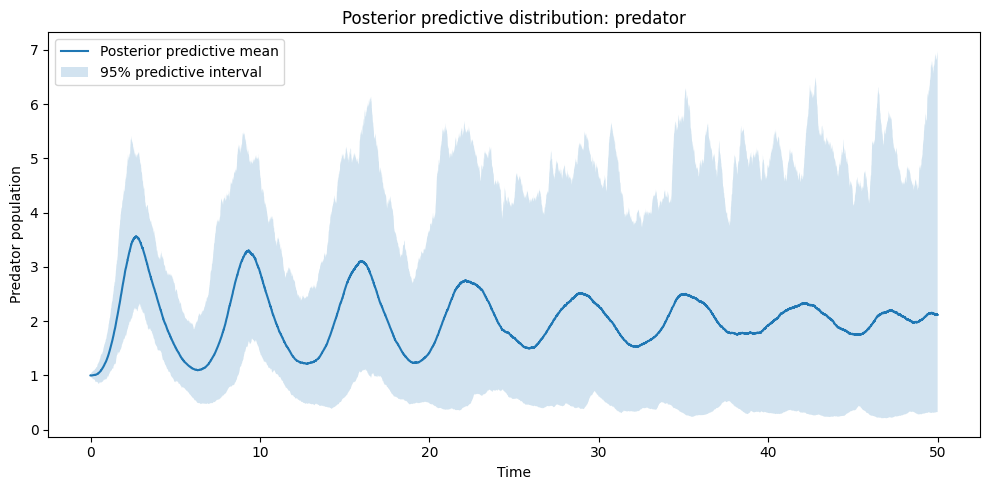

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    t,
    X_mean[:, 1],
    label="Posterior predictive mean"
)

plt.fill_between(
    t,
    X_lower[:, 1],
    X_upper[:, 1],
    alpha=0.2,
    label="95% predictive interval"
)

plt.xlabel("Time")
plt.ylabel("Predator population")
plt.title("Posterior predictive distribution: predator")

plt.legend()
plt.tight_layout()
plt.show()

In [49]:
X_process = np.zeros(
    (n_samples, len(t), 2)
)

for j in range(n_samples):

    X_process[j] = simulate_lv_operator(
        O=O_bayes,
        X0=X0,
        t=t,
        sigma1=sigma1,
        sigma2=sigma2,
        rng=rng
    )

In [53]:
mean_process = np.mean(
    X_process,
    axis=0
)

lower_process = np.percentile(
    X_process,
    2.5,
    axis=0
)

upper_process = np.percentile(
    X_process,
    97.5,
    axis=0
)

mean_bayes = np.mean(
    X_pred,
    axis=0
)

lower_bayes = np.percentile(
    X_pred,
    2.5,
    axis=0
)

upper_bayes = np.percentile(
    X_pred,
    97.5,
    axis=0
)

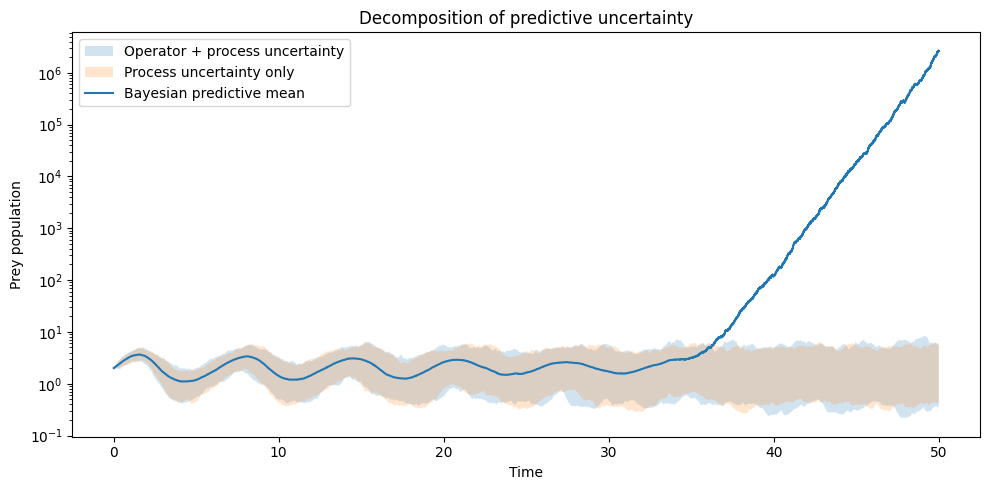

In [ ]:
plt.figure(figsize=(10, 5))

plt.fill_between(
    t,
    lower_bayes[:, 0],
    upper_bayes[:, 0],
    alpha=0.2,
    label="Operator + process uncertainty"
)

plt.fill_between(
    t,
    lower_process[:, 0],
    upper_process[:, 0],
    alpha=0.2,
    label="Process uncertainty only"
)

plt.semilogy(
    t,
    X_mean[:, 0],
    label="Bayesian predictive mean"
)

plt.xlabel("Time")
plt.ylabel("Prey population")
plt.title("Decomposition of predictive uncertainty")

plt.legend()
plt.tight_layout()
plt.show()

## **Stochasstic heat equation**

$$
\mathrm{d}u_t = \nu * u_{xx} \mathrm{d}t + \sigma \mathrm{d} W_t
$$

dx = 2.4544e-02
dt = 8.0308e-04
Nt = 6226


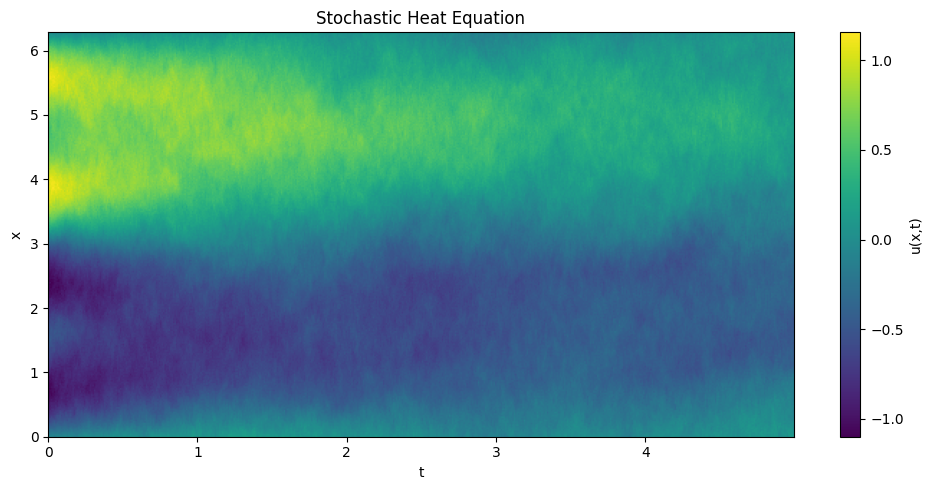

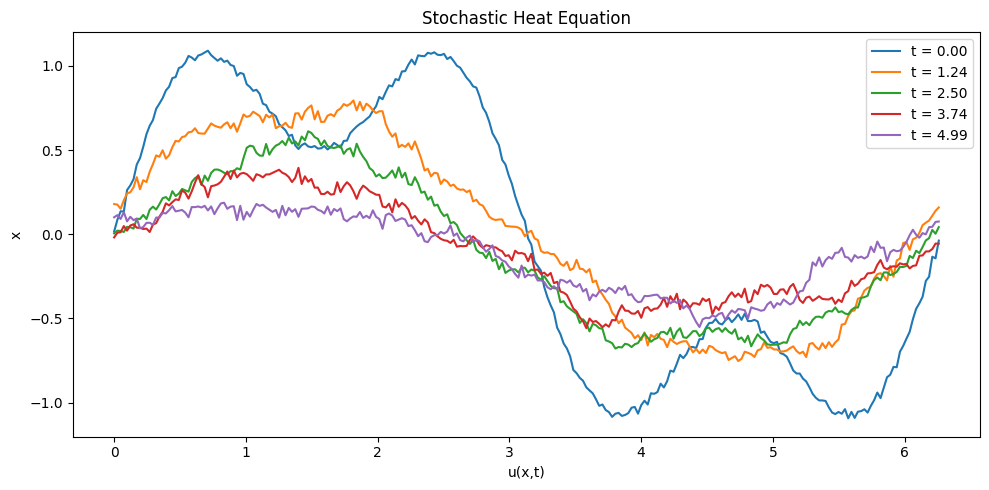

In [38]:
# ============================================================
# Stochastic Heat Equation
#
#     du = nu * u_xx dt + sigma dW
#
# Periodic boundary conditions
# Euler-Maruyama time integration
# ============================================================


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

L = 2.0 * np.pi
Nx = 256
T = 5.0

nu = 0.3       # diffusivity
sigma = 0.1    # noise strength

dx = L / Nx
x = np.arange(Nx) * dx


# ------------------------------------------------------------
# Time step
# ------------------------------------------------------------
# Explicit diffusion stability condition:
#
#     dt <= dx^2 / (2 nu)
#
# We use a safety factor.

dt = 0.4 * dx**2 / nu

Nt = int(np.ceil(T / dt))
dt = T / Nt

print(f"dx = {dx:.4e}")
print(f"dt = {dt:.4e}")
print(f"Nt = {Nt}")


# ------------------------------------------------------------
# Initial condition
# ------------------------------------------------------------

u = np.sin(x) + 0.5 * np.sin(3*x)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

save_every = max(1, Nt // 500)

snapshots = []
times = []


# ------------------------------------------------------------
# Time integration
# ------------------------------------------------------------

for n in range(Nt):

    # --------------------------------------------------------
    # Second spatial derivative
    # --------------------------------------------------------

    u_xx = (
        np.roll(u, -1)
        - 2.0 * u
        + np.roll(u, 1)
    ) / dx**2

    # --------------------------------------------------------
    # Deterministic drift
    # --------------------------------------------------------

    drift = nu * u_xx

    # --------------------------------------------------------
    # Space-time white noise
    #
    # dW_i ~ sqrt(dt / dx) N(0,1)
    # --------------------------------------------------------

    dW = np.sqrt(dt / dx) * np.random.randn(Nx)

    # --------------------------------------------------------
    # Euler-Maruyama
    # --------------------------------------------------------

    u = u + drift * dt + sigma * dW

    # --------------------------------------------------------
    # Save snapshots
    # --------------------------------------------------------

    if n % save_every == 0:
        snapshots.append(u.copy())
        times.append(n * dt)


snapshots = np.array(snapshots)
times = np.array(times)


# ============================================================
# Space-time plot
# ============================================================

plt.figure(figsize=(10, 5))

plt.imshow(
    snapshots.T,
    aspect="auto",
    # extent=[0, L, times[-1], times[0]],
    extent=[times[0], times[-1], 0, L],
    origin="upper"
)

plt.ylabel("x")
plt.xlabel("t")
plt.title("Stochastic Heat Equation")

plt.colorbar(label="u(x,t)")

plt.tight_layout()
plt.show()


# ============================================================
# Individual snapshots
# ============================================================

plt.figure(figsize=(10, 5))

indices = np.linspace(
    0,
    len(times) - 1,
    5
).astype(int)

for i in indices:
    plt.plot(
        x,
        snapshots[i],
        label=f"t = {times[i]:.2f}"
    )

plt.ylabel("x")
plt.xlabel("u(x,t)")
plt.title("Stochastic Heat Equation")

plt.legend()
plt.tight_layout()
plt.show()

## **Stochasstic advection-diffusion equation**

dx = 2.4544e-02
dt = 1.2048e-02
Nt = 830


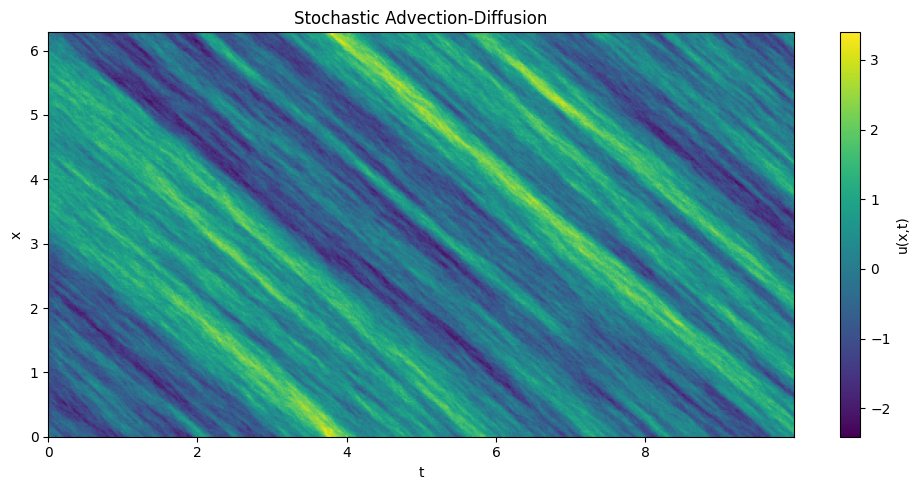

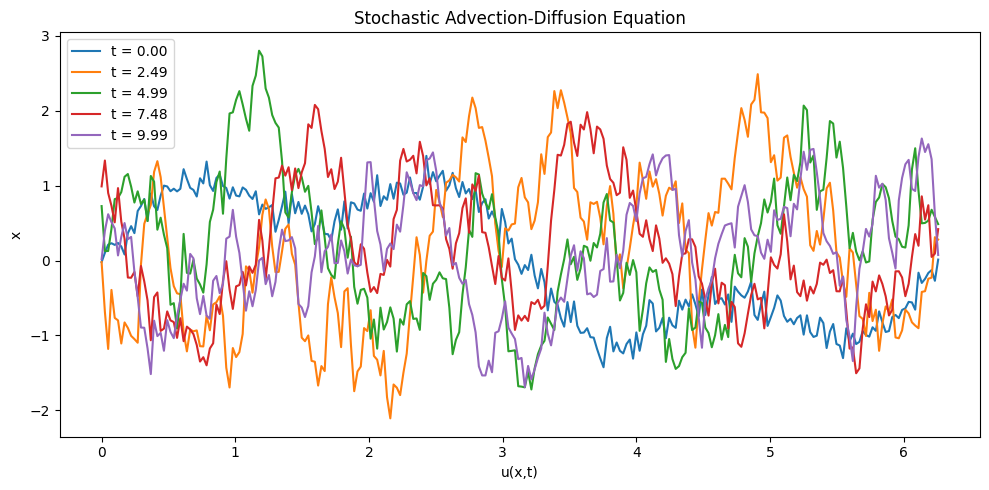

In [30]:
# ============================================================
# Stochastic Advection-Diffusion Equation
#
#     du = (-c u_x + nu u_xx) dt + sigma dW
#
# Periodic boundary conditions
# Euler-Maruyama time integration
# ============================================================

# -------------------------
# Parameters
# -------------------------
L = 2.0 * np.pi       # domain length
Nx = 256              # spatial resolution
T = 10.0              # final time

c = 1.0               # advection velocity
nu = 0.01             # diffusivity
sigma = 0.2            # noise strength

dx = L / Nx
x = np.arange(Nx) * dx

# Stability condition for explicit diffusion
dt = 0.2 * dx**2 / nu
Nt = int(T / dt)

print(f"dx = {dx:.4e}")
print(f"dt = {dt:.4e}")
print(f"Nt = {Nt}")

# -------------------------
# Initial condition
# -------------------------
u = np.sin(x) + 0.5 * np.sin(3*x)

# Store snapshots
save_every = max(1, Nt // 500)
snapshots = []
times = []

# -------------------------
# Time integration
# -------------------------
for n in range(Nt):

    # Periodic derivatives
    u_x = (np.roll(u, -1) - np.roll(u, 1)) / (2.0 * dx)

    u_xx = (
        np.roll(u, -1)
        - 2.0 * u
        + np.roll(u, 1)
    ) / dx**2

    # Deterministic drift
    drift = -c * u_x + nu * u_xx

    # Euler-Maruyama noise
    dW = np.sqrt(dt / dx) * np.random.randn(Nx)

    # Update
    u = u + drift * dt + sigma * dW

    # Save
    if n % save_every == 0:
        snapshots.append(u.copy())
        times.append(n * dt)

snapshots = np.array(snapshots)
times = np.array(times)

# -------------------------
# Plot space-time solution
# -------------------------
plt.figure(figsize=(10, 5))

plt.imshow(
    snapshots.T,
    aspect="auto",
    # extent=[0, L, times[-1], times[0]],
    extent=[times[0], times[-1], 0, L],
    # origin="upper"
)

plt.ylabel("x")
plt.xlabel("t")
plt.title("Stochastic Advection-Diffusion")
plt.colorbar(label="u(x,t)")
plt.tight_layout()
plt.show()


# ============================================================
# Individual snapshots
# ============================================================

plt.figure(figsize=(10, 5))

indices = np.linspace(
    0,
    len(times) - 1,
    5
).astype(int)

for i in indices:
    plt.plot(
        x,
        snapshots[i],
        label=f"t = {times[i]:.2f}"
    )

plt.ylabel("x")
plt.xlabel("u(x,t)")
plt.title("Stochastic Advection-Diffusion Equation")

plt.legend()
plt.tight_layout()
plt.show()

## **Stochasstic Burgers equation**

dx = 2.4544e-02
Final time = 5.0000
Number of saved snapshots = 417
Final max|u| = 0.4821


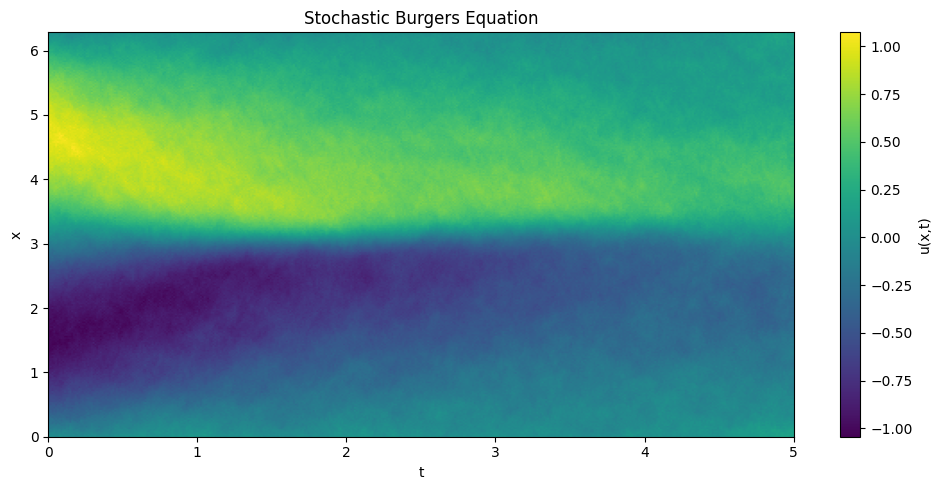

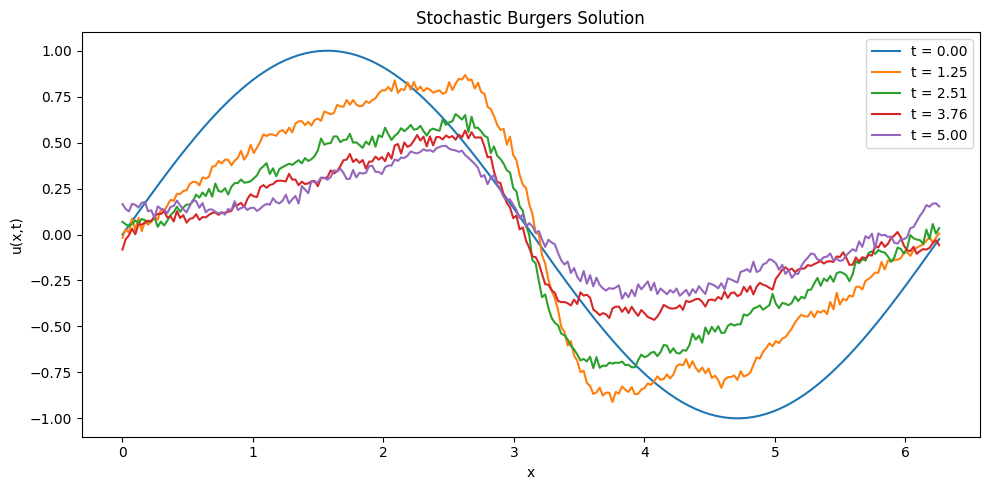

In [39]:
# ============================================================
# Stochastic Burgers Equation
#
#     du = [-1/2 (u^2)_x + nu u_xx] dt + sigma dW
#
# Periodic boundary conditions
#
# Numerical method:
#   - Lax-Friedrichs flux for nonlinear advection
#   - centered difference for diffusion
#   - Euler-Maruyama for stochastic forcing
# ============================================================


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

L = 2.0 * np.pi
Nx = 256
T = 5.0

nu = 0.1
sigma = 0.05

# CFL parameters
CFL = 0.2

dx = L / Nx

# ------------------------------------------------------------
# Initial condition
# ------------------------------------------------------------

x = np.arange(Nx) * dx

u = np.sin(x)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

snapshots = [u.copy()]
times = [0.0]

t = 0.0

# ------------------------------------------------------------
# Time integration
# ------------------------------------------------------------

while t < T:

    # --------------------------------------------------------
    # Adaptive timestep based on current maximum velocity
    # --------------------------------------------------------

    umax = np.max(np.abs(u))

    # Avoid division by zero
    if umax > 1e-12:
        dt_adv = CFL * dx / umax
    else:
        dt_adv = 1e-2

    # Diffusion stability condition
    dt_diff = 0.4 * dx**2 / nu

    # Use the smaller timestep
    dt = min(dt_adv, dt_diff, T - t)

    # --------------------------------------------------------
    # Burgers nonlinear flux
    #
    # f(u) = u^2 / 2
    #
    # Lax-Friedrichs flux:
    #
    # F_{i+1/2} =
    #   0.5 [f(u_i) + f(u_{i+1})]
    #   - 0.5 alpha (u_{i+1} - u_i)
    # --------------------------------------------------------

    f = 0.5 * u**2

    alpha = np.max(np.abs(u))

    u_right = np.roll(u, -1)

    flux = (
        0.5 * (f + 0.5 * u_right**2)
        - 0.5 * alpha * (u_right - u)
    )

    # Flux divergence
    flux_left = np.roll(flux, 1)

    nonlinear = -(flux - flux_left) / dx

    # --------------------------------------------------------
    # Diffusion
    # --------------------------------------------------------

    u_xx = (
        np.roll(u, -1)
        - 2.0 * u
        + np.roll(u, 1)
    ) / dx**2

    diffusion = nu * u_xx

    # --------------------------------------------------------
    # Stochastic forcing
    #
    # Space-time white noise
    # --------------------------------------------------------

    dW = np.sqrt(dt / dx) * np.random.randn(Nx)

    # --------------------------------------------------------
    # Euler-Maruyama
    # --------------------------------------------------------

    u = u + (nonlinear + diffusion) * dt + sigma * dW

    t += dt

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if len(times) == 0 or t - times[-1] >= 0.01 or t >= T:
        snapshots.append(u.copy())
        times.append(t)

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if not np.all(np.isfinite(u)):
        raise RuntimeError(
            f"Solution became unstable at t={t:.4e}, "
            f"max|u|={np.max(np.abs(u))}"
        )


snapshots = np.array(snapshots)
times = np.array(times)

print(f"dx = {dx:.4e}")
print(f"Final time = {times[-1]:.4f}")
print(f"Number of saved snapshots = {len(times)}")
print(f"Final max|u| = {np.max(np.abs(u)):.4f}")


# ============================================================
# Space-time plot
# ============================================================

plt.figure(figsize=(10, 5))

plt.imshow(
    snapshots.T,
    aspect="auto",
    # extent=[0, L, times[-1], times[0]],
    extent=[times[0], times[-1], 0, L],
    origin="upper"
)

plt.ylabel("x")
plt.xlabel("t")
plt.title("Stochastic Burgers Equation")

plt.colorbar(label="u(x,t)")

plt.tight_layout()
plt.show()


# ============================================================
# Individual snapshots
# ============================================================

plt.figure(figsize=(10, 5))

indices = np.linspace(
    0,
    len(times) - 1,
    5
).astype(int)

for i in indices:
    plt.plot(
        x,
        snapshots[i],
        label=f"t = {times[i]:.2f}"
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Stochastic Burgers Solution")

plt.legend()
plt.tight_layout()
plt.show()